# Olist Pricing & BI Analytics
## 04 - Data Profiling & EDA
### Análise exploratória dos dados brutos para identificar qualidade, padrões e oportunidades de pricing

**Author:** Gisele CP  
**Date:** 2026-05-27  
**Stack:** Python | Snowflake | Pandas | Matplotlib | Seaborn

In [73]:
# ================================================
# INSTALAÇÃO DAS DEPENDÊNCIAS
# ================================================
# Instala as bibliotecas necessárias para o projeto
# -q suprime o output verbose da instalação
!pip install snowflake-connector-python -q

In [ ]:
# ================================================
# STEP 1: SETUP & CONEXÃO COM SNOWFLAKE
# ================================================
# Importação das bibliotecas necessárias para
# análise de dados, visualização e conexão com Snowflake

import snowflake.connector          # conector oficial do Snowflake
import pandas as pd                 # manipulação e análise de dados
import matplotlib.pyplot as plt     # criação de gráficos base
import seaborn as sns               # visualizações estatísticas avançadas
from google.colab import userdata   # acesso seguro aos secrets do Colab
import warnings                     # controle de alertas do Python
warnings.filterwarnings('ignore')   # suprime warnings desnecessários

# Estabelece conexão com o Snowflake
# As credenciais ficam nos Secrets do Colab — nunca expostas no código
conn = snowflake.connector.connect(
    account=userdata.get('SNOWFLAKE_ACCOUNT'),      # identificador único da conta Snowflake
    user=userdata.get('SNOWFLAKE_USER'),             # usuário de acesso
    password=userdata.get('SNOWFLAKE_PASSWORD'),     # senha do usuário
    warehouse=userdata.get('SNOWFLAKE_WAREHOUSE'),   # warehouse de processamento das queries
    database=userdata.get('SNOWFLAKE_DATABASE'),     # database do projeto
    schema=userdata.get('SNOWFLAKE_SCHEMA')          # schema raw — dados brutos
)

# Configuração padrão de estilo para todos os gráficos do notebook
sns.set_theme(style='whitegrid')         # fundo branco com grade — mais legível
plt.rcParams['figure.figsize'] = (8, 4) # tamanho padrão dos gráficos
plt.rcParams['font.size'] = 10           # tamanho padrão da fonte

# Confirmação de conexão bem sucedida
print("✅ Conexão com Snowflake estabelecida!")
print(f"✅ Database: {userdata.get('SNOWFLAKE_DATABASE')}")
print(f"✅ Schema:   {userdata.get('SNOWFLAKE_SCHEMA')}")
print(f"✅ Warehouse:{userdata.get('SNOWFLAKE_WAREHOUSE')}")

✅ Conexão com Snowflake estabelecida!
✅ Database: olist_db
✅ Schema:   raw
✅ Warehouse:olist_wh


📊 Volume de dados por tabela:
              tabela   total
         geolocation 1000163
         order_items  112650
      order_payments  103886
           customers   99441
              orders   99441
       order_reviews   99224
            products   32951
             sellers    3095
category_translation      71


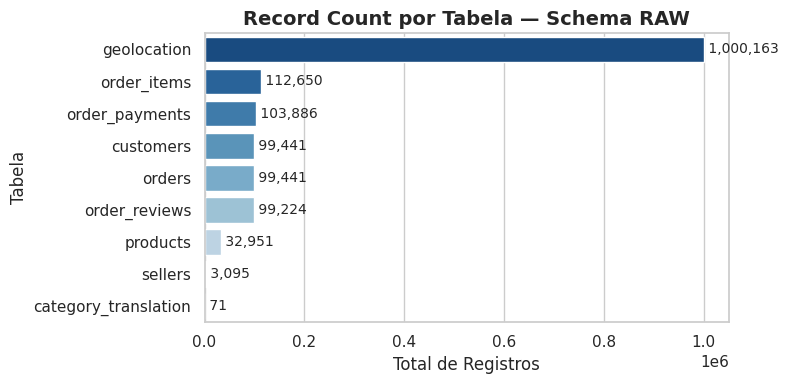

In [ ]:
# ================================================
# STEP 2: RECORD COUNT POR TABELA
# ================================================
# Valida o volume de dados carregados em cada tabela
# Confirma que todos os 9 CSVs foram ingeridos corretamente

# Query UNION ALL para contar registros de todas as tabelas em uma só consulta
query = """
SELECT 'customers' AS tabela, COUNT(*) AS total FROM olist_db.raw.customers
UNION ALL
SELECT 'geolocation', COUNT(*) FROM olist_db.raw.geolocation
UNION ALL
SELECT 'order_items', COUNT(*) FROM olist_db.raw.order_items
UNION ALL
SELECT 'order_payments', COUNT(*) FROM olist_db.raw.order_payments
UNION ALL
SELECT 'order_reviews', COUNT(*) FROM olist_db.raw.order_reviews
UNION ALL
SELECT 'orders', COUNT(*) FROM olist_db.raw.orders
UNION ALL
SELECT 'products', COUNT(*) FROM olist_db.raw.products
UNION ALL
SELECT 'sellers', COUNT(*) FROM olist_db.raw.sellers
UNION ALL
SELECT 'category_translation', COUNT(*) FROM olist_db.raw.category_translation
ORDER BY total DESC
"""

# Executa a query e carrega o resultado em um DataFrame pandas
df_counts = pd.read_sql(query, conn)

# Snowflake retorna colunas em maiúsculo — padroniza para minúsculo
df_counts.columns = df_counts.columns.str.lower()

# Exibe tabela com os resultados no console
print("📊 Volume de dados por tabela:")
print(df_counts.to_string(index=False))

# Cria figura e eixo para o gráfico
fig, ax = plt.subplots(figsize=(8, 4))

# Gráfico de barras horizontal — facilita leitura dos nomes das tabelas
sns.barplot(data=df_counts, x='total', y='tabela', palette='Blues_r', ax=ax)

# Adiciona o valor numérico ao final de cada barra para facilitar leitura
for i, row in df_counts.iterrows():
    ax.text(row['total'],              # posição x = valor da barra
            i,                          # posição y = linha da tabela
            f" {row['total']:,}",       # texto formatado com separador de milhar
            va='center',                # alinhamento vertical centralizado
            fontsize=10)                # tamanho da fonte do valor

# Configurações do gráfico
ax.set_title('Record Count por Tabela — Schema RAW', fontsize=14, fontweight='bold')
ax.set_xlabel('Total de Registros')
ax.set_ylabel('Tabela')
plt.tight_layout()  # ajusta margens automaticamente

plt.savefig('step_02_Record Count por Tabela — Schema RAW.png', dpi=150, bbox_inches='tight')

plt.show()

📊 Total de itens:  112,650
💰 Preço mínimo:    R$ 0.85
💰 Preço máximo:    R$ 6735.00
💰 Preço médio:     R$ 120.65
💰 Preço mediana:   R$ 74.99
💰 Desvio padrão:   R$ 183.63
📦 Frete médio:     R$ 19.99


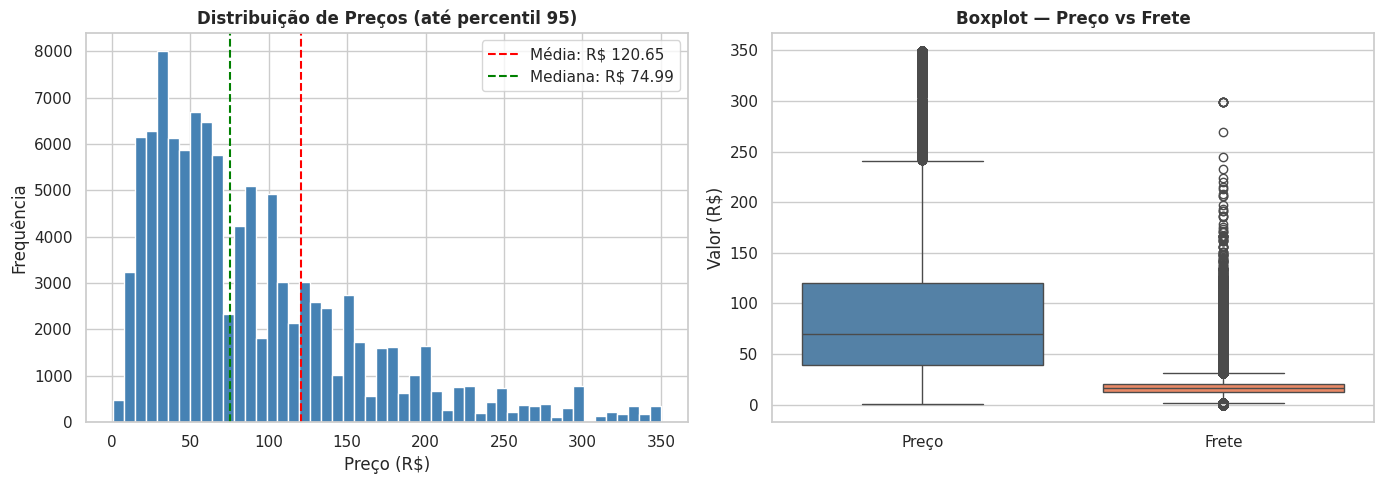

In [ ]:
# ================================================
# STEP 3: DISTRIBUIÇÃO DE PREÇOS
# ================================================
# Analisa a distribuição dos preços dos produtos
# para identificar concentração, dispersão e outliers
# Fundamental para a análise de pricing do projeto

# Busca preço e frete de todos os itens vendidos
query = """
SELECT
    CAST(price AS FLOAT) AS price,                   -- converte VARCHAR para número
    CAST(freight_value AS FLOAT) AS freight_value    -- converte VARCHAR para número
FROM olist_db.raw.order_items
"""

# Carrega dados e padroniza nomes das colunas para minúsculo
df_prices = pd.read_sql(query, conn)
df_prices.columns = df_prices.columns.str.lower()

# Estatísticas descritivas principais
print(f"📊 Total de itens:  {len(df_prices):,}")
print(f"💰 Preço mínimo:    R$ {df_prices['price'].min():.2f}")
print(f"💰 Preço máximo:    R$ {df_prices['price'].max():.2f}")
print(f"💰 Preço médio:     R$ {df_prices['price'].mean():.2f}")
print(f"💰 Preço mediana:   R$ {df_prices['price'].median():.2f}")
print(f"💰 Desvio padrão:   R$ {df_prices['price'].std():.2f}")
print(f"📦 Frete médio:     R$ {df_prices['freight_value'].mean():.2f}")

# Remove outliers extremos para melhor visualização
# Usa percentil 95 — mantém 95% dos dados, remove apenas os mais extremos
price_95 = df_prices['price'].quantile(0.95)  # calcula o percentil 95
df_plot = df_prices[df_prices['price'] <= price_95]  # filtra acima do percentil

# Cria figura com 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Histograma de distribuição de preços
axes[0].hist(df_plot['price'],          # dados filtrados até percentil 95
             bins=50,                    # 50 barras para boa granularidade
             color='steelblue',          # cor das barras
             edgecolor='white')          # borda branca entre barras

# Linha vertical vermelha indicando a média
axes[0].axvline(df_prices['price'].mean(),
                color='red',
                linestyle='--',
                label=f"Média: R$ {df_prices['price'].mean():.2f}")

# Linha vertical verde indicando a mediana
axes[0].axvline(df_prices['price'].median(),
                color='green',
                linestyle='--',
                label=f"Mediana: R$ {df_prices['price'].median():.2f}")

axes[0].set_title('Distribuição de Preços (até percentil 95)', fontweight='bold')
axes[0].set_xlabel('Preço (R$)')
axes[0].set_ylabel('Frequência')
axes[0].legend()  # exibe legenda com média e mediana

# Gráfico 2: Boxplot comparando preço vs frete
# pd.melt transforma colunas em linhas para o seaborn entender
df_boxplot = pd.melt(df_plot[['price', 'freight_value']],
                     var_name='tipo',    # nome da coluna com o tipo
                     value_name='valor') # nome da coluna com o valor

sns.boxplot(data=df_boxplot,
            x='tipo',                    # eixo x = tipo (price ou freight)
            y='valor',                   # eixo y = valor em R$
            palette=['steelblue', 'coral'], # cores distintas para cada tipo
            ax=axes[1])

axes[1].set_title('Boxplot — Preço vs Frete', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Valor (R$)')
axes[1].set_xticklabels(['Preço', 'Frete'])  # labels em português

plt.tight_layout()  # ajusta margens automaticamente

plt.savefig('step_03_distribuicao_precos.png', dpi=150, bbox_inches='tight')

plt.show()

📊 Top 15 Categorias por Receita:
 product_category_name  total_revenue  avg_price
          beleza_saude     1258681.34     130.16
    relogios_presentes     1205005.68     201.14
       cama_mesa_banho     1036988.68      93.30
         esporte_lazer      988048.97     114.34
informatica_acessorios      911954.32     116.51
      moveis_decoracao      729762.49      87.56
            cool_stuff      635290.85     167.36
 utilidades_domesticas      632248.66      90.79
            automotivo      592720.11     139.96
    ferramentas_jardim      485256.46     111.63
            brinquedos      483946.60     117.55
                 bebes      411764.89     134.34
            perfumaria      399124.87     116.74
             telefonia      323667.53      71.21
     moveis_escritorio      273960.70     162.01


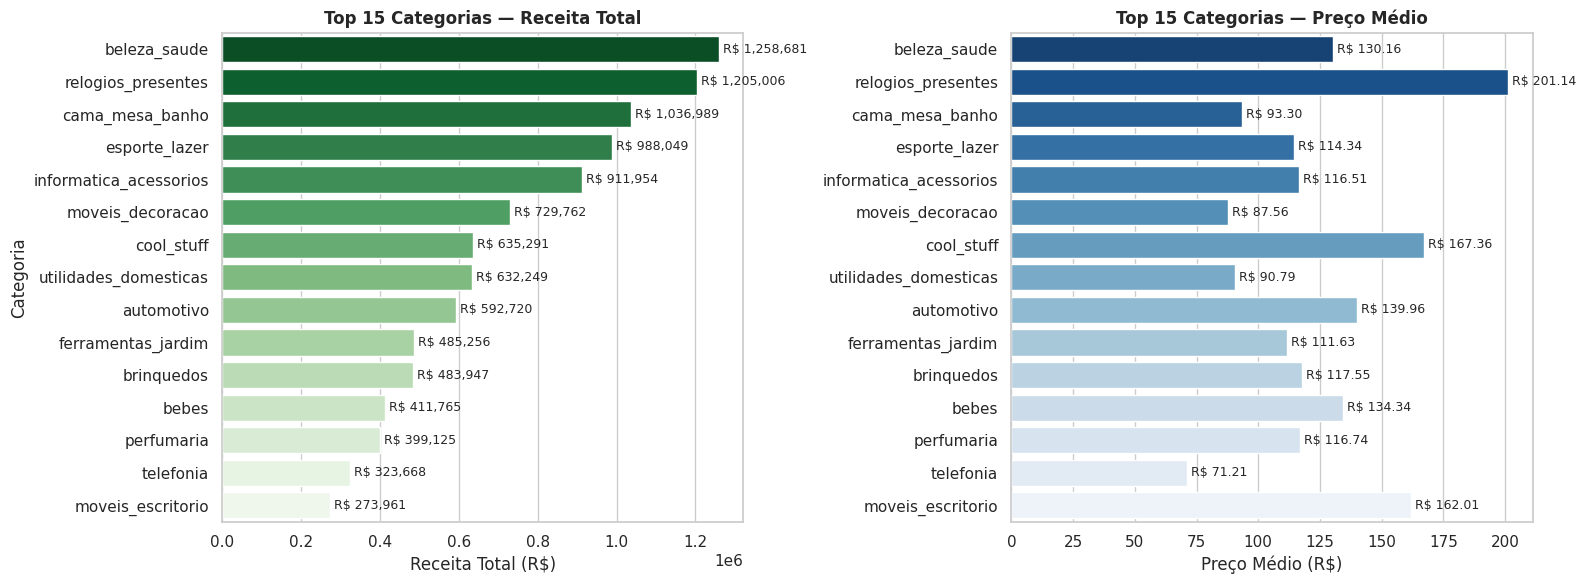

In [ ]:
# ================================================
# STEP 4: RECEITA POR CATEGORIA
# ================================================
# Identifica as categorias mais relevantes em receita
# Fundamental para priorizar análise de pricing

# Query com JOIN entre order_items e products para trazer a categoria
query = """
SELECT
    p.product_category_name,                        -- nome da categoria
    COUNT(DISTINCT oi.order_id) AS total_orders,    -- pedidos únicos
    COUNT(oi.order_item_id) AS total_items,         -- total de itens vendidos
    ROUND(AVG(CAST(oi.price AS FLOAT)), 2) AS avg_price,    -- preço médio
    ROUND(SUM(CAST(oi.price AS FLOAT)), 2) AS total_revenue -- receita total
FROM olist_db.raw.order_items oi
LEFT JOIN olist_db.raw.products p                   -- traz categoria do produto
    ON oi.product_id = p.product_id
WHERE p.product_category_name IS NOT NULL           -- remove sem categoria
GROUP BY p.product_category_name
ORDER BY total_revenue DESC
LIMIT 15                                            -- top 15 categorias
"""

# Carrega dados e padroniza colunas
df_revenue = pd.read_sql(query, conn)
df_revenue.columns = df_revenue.columns.str.lower()

# Exibe tabela resumida no console
print("📊 Top 15 Categorias por Receita:")
print(df_revenue[['product_category_name', 'total_revenue', 'avg_price']].to_string(index=False))

# Cria figura com 2 gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Receita total por categoria
sns.barplot(data=df_revenue,
            x='total_revenue',                  # eixo x = receita total
            y='product_category_name',          # eixo y = nome da categoria
            palette='Greens_r',                 # paleta verde — remete a dinheiro
            ax=axes[0])

# Adiciona valores nas barras formatados em R$
for i, row in df_revenue.iterrows():
    axes[0].text(row['total_revenue'],
                 i,
                 f" R$ {row['total_revenue']:,.0f}",  # formato monetário
                 va='center',
                 fontsize=9)

axes[0].set_title('Top 15 Categorias — Receita Total', fontweight='bold')
axes[0].set_xlabel('Receita Total (R$)')
axes[0].set_ylabel('Categoria')

# Gráfico 2: Preço médio por categoria
sns.barplot(data=df_revenue,
            x='avg_price',                      # eixo x = preço médio
            y='product_category_name',          # eixo y = nome da categoria
            palette='Blues_r',                  # paleta azul — diferencia do primeiro
            ax=axes[1])

# Adiciona valores nas barras formatados em R$
for i, row in df_revenue.iterrows():
    axes[1].text(row['avg_price'],
                 i,
                 f" R$ {row['avg_price']:,.2f}",  # formato com 2 casas decimais
                 va='center',
                 fontsize=9)

axes[1].set_title('Top 15 Categorias — Preço Médio', fontweight='bold')
axes[1].set_xlabel('Preço Médio (R$)')
axes[1].set_ylabel('')  # remove label do eixo y — já está no gráfico da esquerda

plt.tight_layout()  # ajusta margens automaticamente

plt.savefig('step_04_receita_categoria.png', dpi=150, bbox_inches='tight')

plt.show()

📊 Distribuição de Status dos Pedidos:
order_status  total  percentual
   delivered  96478       97.02
     shipped   1107        1.11
    canceled    625        0.63
 unavailable    609        0.61
    invoiced    314        0.32
  processing    301        0.30
     created      5        0.01
    approved      2        0.00


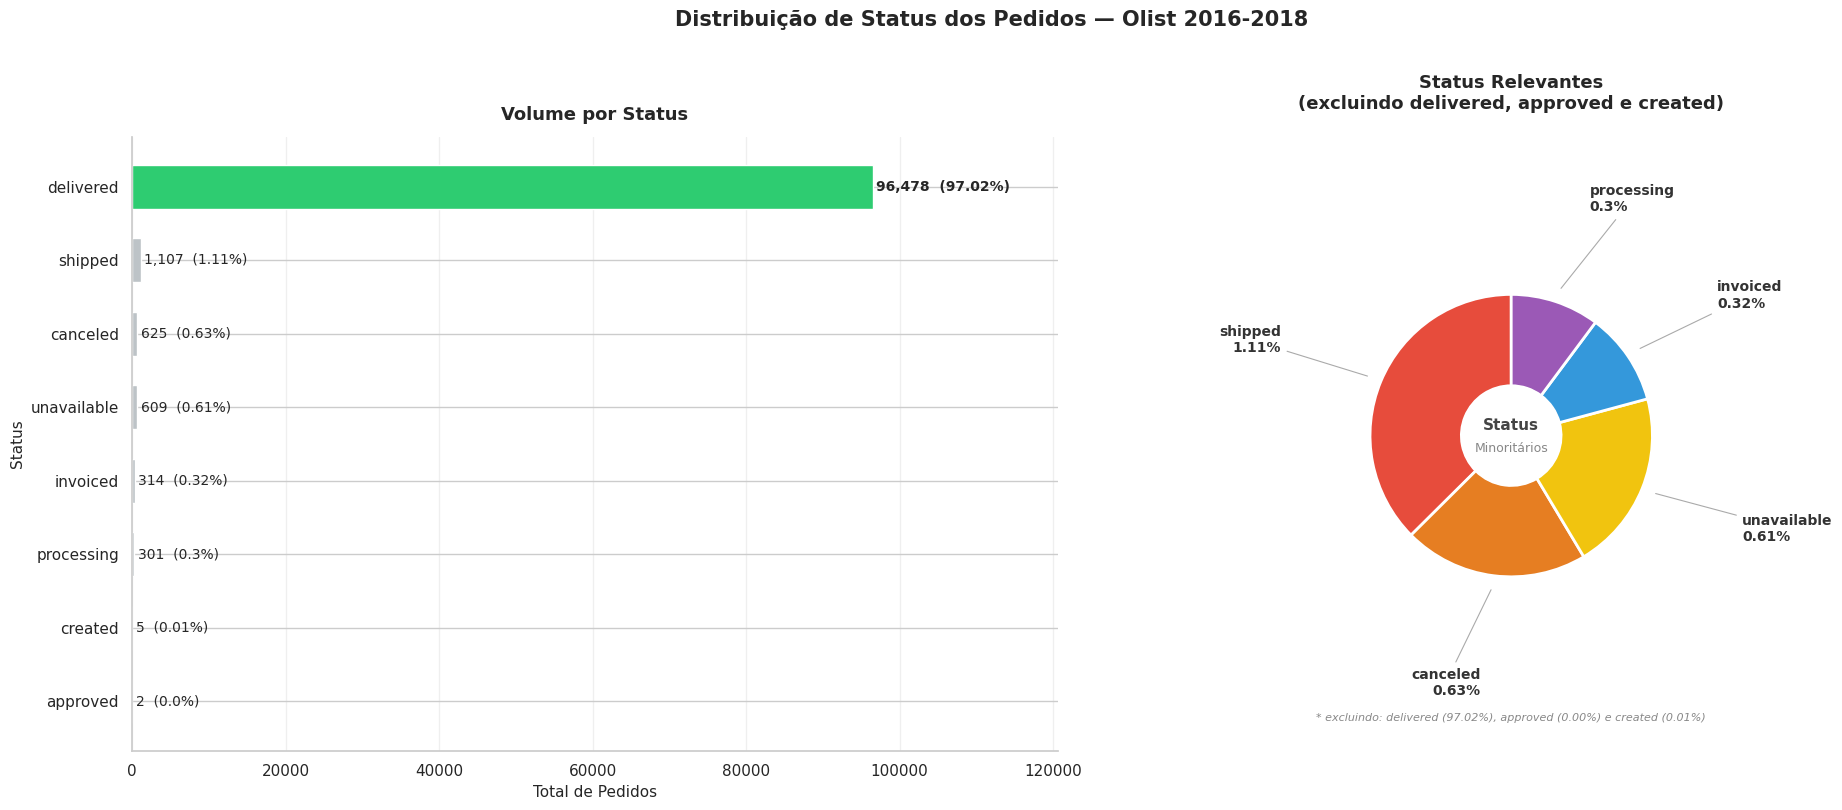

In [ ]:
# ================================================
# STEP 5: DISTRIBUIÇÃO DE STATUS DOS PEDIDOS
# ================================================
# Analisa a distribuição dos status dos pedidos
# Importante para filtrar apenas pedidos entregues
# na análise de pricing — pedidos cancelados distorcem os dados

import numpy as np  # biblioteca para cálculos matemáticos — usada nos ângulos da rosca

query = """
SELECT
    order_status,
    COUNT(*) AS total,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentual
FROM olist_db.raw.orders
GROUP BY order_status
ORDER BY total DESC
"""

# Carrega dados e padroniza colunas para minúsculo
df_status = pd.read_sql(query, conn)
df_status.columns = df_status.columns.str.lower()

print("📊 Distribuição de Status dos Pedidos:")
print(df_status.to_string(index=False))

# Paleta de cores — verde para delivered, cinza para demais
colors_bar = ['#2ecc71' if s == 'delivered' else '#bdc3c7'
              for s in df_status['order_status']]

# Cria figura com 2 gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Distribuição de Status dos Pedidos — Olist 2016-2018',
             fontsize=15, fontweight='bold', y=1.01)

# ── Gráfico 1: Barras horizontais — todos os status ────────
axes[0].barh(
    df_status['order_status'],       # categorias no eixo y
    df_status['total'],              # valores no eixo x
    color=colors_bar,                # verde = delivered, cinza = demais
    edgecolor='white',               # borda branca entre barras
    height=0.6)                      # altura das barras

# Adiciona valor + percentual ao final de cada barra
for i, row in df_status.iterrows():
    axes[0].text(
        row['total'] + 500,          # offset à direita para não sobrepor a barra
        i,                           # posição vertical alinhada à barra
        f"{row['total']:,}  ({row['percentual']}%)",
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold' if row['order_status'] == 'delivered' else 'normal')

axes[0].invert_yaxis()               # maior valor no topo
axes[0].set_title('Volume por Status', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Total de Pedidos', fontsize=11)
axes[0].set_ylabel('Status', fontsize=11)
axes[0].set_xlim(0, df_status['total'].max() * 1.25)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='x', alpha=0.3)

# ── Gráfico 2: Rosca status relevantes ─────────────────────
# Remove delivered (97%) — domina visualmente
# Remove approved (2) e created (5) — irrelevantes estatisticamente
df_minority = df_status[
    ~df_status['order_status'].isin(['delivered', 'approved', 'created'])
].copy()

# Recalcula percentual apenas dos status exibidos para o gráfico
# os percentuais originais são mantidos no label para contexto real
colors_pie = ['#e74c3c',   # shipped — vermelho
              '#e67e22',   # canceled — laranja
              '#f1c40f',   # unavailable — amarelo
              '#3498db',   # invoiced — azul
              '#9b59b6']   # processing — roxo

# Cria gráfico de rosca
wedges, texts = axes[1].pie(
    df_minority['total'],                        # valores das fatias
    startangle=90,                               # inicia no topo
    colors=colors_pie[:len(df_minority)],        # cores distintas por status
    wedgeprops={'edgecolor': 'white',            # borda branca entre fatias
                'linewidth': 2,
                'width': 0.55},                  # width < 1 = efeito rosca
    radius=0.85,                                 # raio menor — mais espaço para labels
    labels=None                                  # remove labels automáticos
)

# Adiciona labels externos com linha conectora
for i, (wedge, row) in enumerate(zip(wedges, df_minority.itertuples())):
    # Calcula ângulo central da fatia
    angle = (wedge.theta2 + wedge.theta1) / 2

    # Coordenadas do label fora da rosca
    x_pos = 1.25 * np.cos(np.radians(angle))
    y_pos = 1.25 * np.sin(np.radians(angle))

    # Alinhamento baseado na posição do label
    ha = 'left' if x_pos > 0 else 'right'

    # Ponto de origem da linha conectora na borda da fatia
    x_arrow = 0.92 * np.cos(np.radians(angle))
    y_arrow = 0.92 * np.sin(np.radians(angle))

    # Anotação com status + percentual original
    axes[1].annotate(
        f"{row.order_status}\n{row.percentual}%",  # status + percentual real
        xy=(x_arrow, y_arrow),                      # origem na fatia
        xytext=(x_pos * 1.2, y_pos * 1.2),          # posição do texto afastado
        ha=ha,
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#333333',
        arrowprops=dict(
            arrowstyle='-',                          # linha simples sem seta
            color='#aaaaaa',                         # cor cinza claro
            lw=0.8)
    )

# Círculo branco no centro — efeito rosca
centre_circle = plt.Circle((0, 0), 0.30, fc='white')
axes[1].add_patch(centre_circle)

# Texto descritivo no centro
axes[1].text(0, 0.06, 'Status',
             ha='center', va='center',
             fontsize=11, fontweight='bold', color='#444444')
axes[1].text(0, -0.08, 'Minoritários',
             ha='center', va='center',
             fontsize=9, color='#888888')

# Nota explicativa abaixo do gráfico
axes[1].text(0, -1.7,
             '* excluindo: delivered (97.02%), approved (0.00%) e created (0.01%)',
             ha='center', va='center',
             fontsize=8, color='#888888',  # texto discreto
             style='italic')

axes[1].set_title('Status Relevantes\n(excluindo delivered, approved e created)',
                  fontsize=13, fontweight='bold', pad=20)

# Espaço generoso para labels externos
axes[1].set_xlim(-1.8, 1.8)
axes[1].set_ylim(-1.9, 1.8)

plt.tight_layout()

plt.savefig('step_05_status_pedidos.png', dpi=150, bbox_inches='tight')

plt.show()

📊 Distribuição de Tipos de Pagamento:
payment_type  total  percentual  avg_ticket  total_revenue
 credit_card  76795       73.92      163.32    12542084.19
      boleto  19784       19.04      145.03     2869361.27
     voucher   5775        5.56       65.70      379436.87
  debit_card   1529        1.47      142.57      217989.79


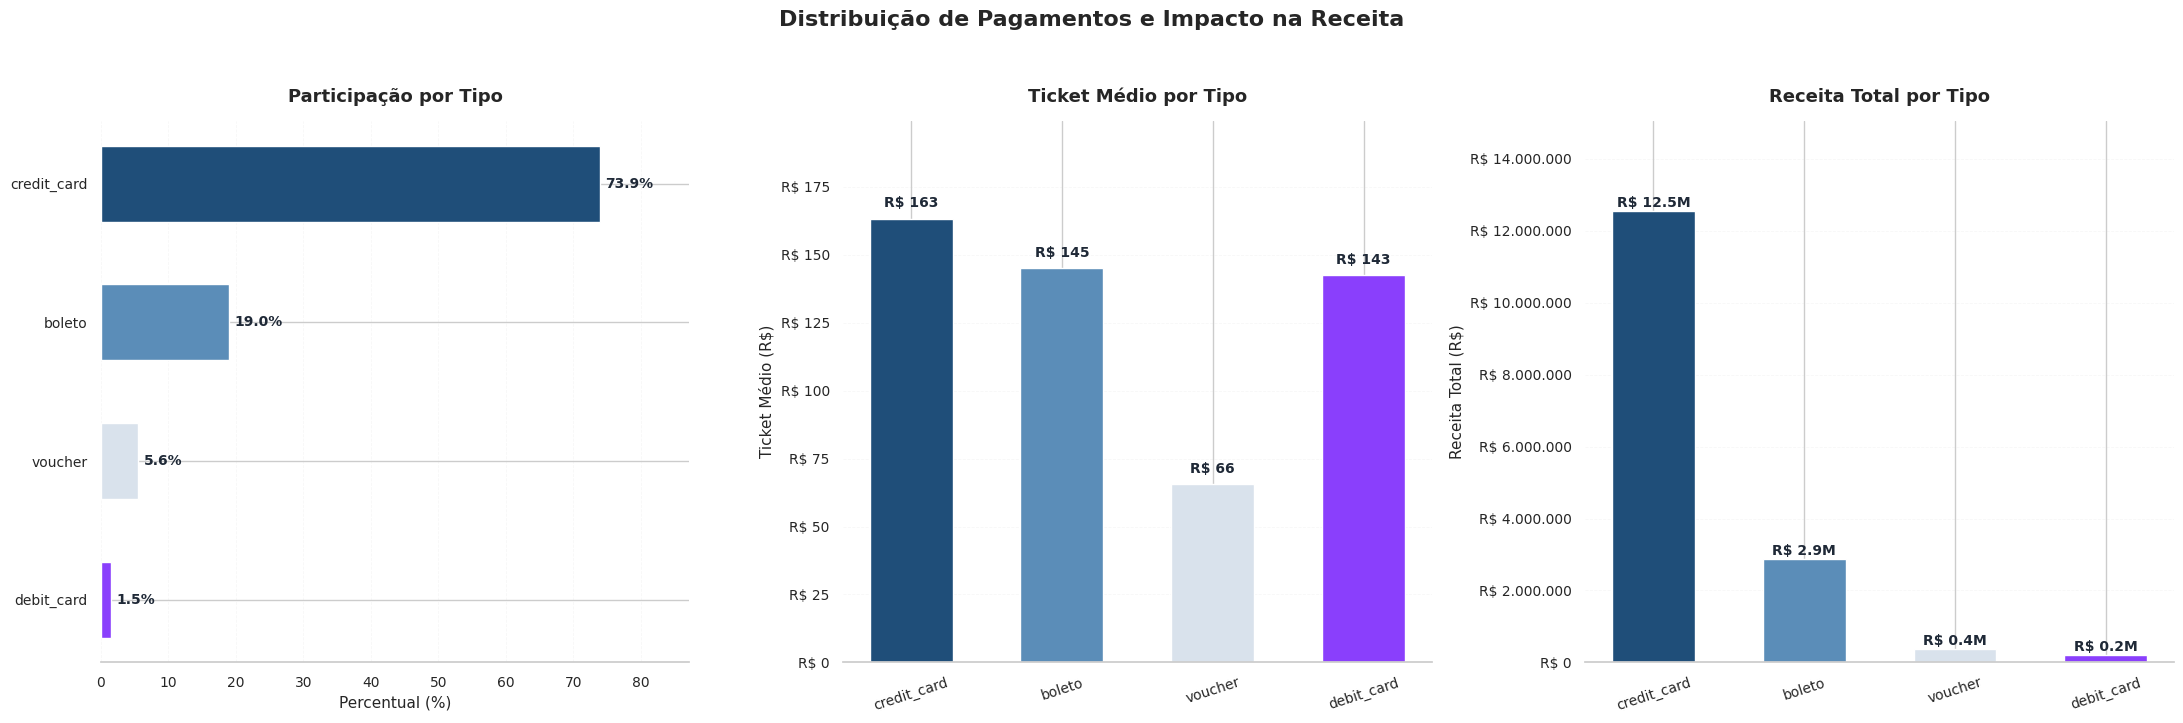

In [ ]:
# ================================================
# STEP 6: TIPOS DE PAGAMENTO
# ================================================
# Objetivo:
# analisar a distribuição dos meios de pagamento,
# ticket médio e impacto na receita total

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ================================================
# CONSULTA SQL
# ================================================
query = """
SELECT
    payment_type,
    COUNT(*) AS total,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentual,
    ROUND(AVG(CAST(payment_value AS FLOAT)), 2) AS avg_ticket,
    ROUND(SUM(CAST(payment_value AS FLOAT)), 2) AS total_revenue
FROM olist_db.raw.order_payments
WHERE payment_type != 'not_defined'
GROUP BY payment_type
ORDER BY total DESC
"""

# ================================================
# CARGA DE DADOS
# ================================================
df_payments = pd.read_sql(query, conn)
df_payments.columns = df_payments.columns.str.lower()

print("📊 Distribuição de Tipos de Pagamento:")
print(df_payments.to_string(index=False))

# ================================================
# CONFIGURAÇÃO VISUAL GLOBAL
# ================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# ================================================
# PALETA PROFISSIONAL
# ================================================
palette = {
    "credit_card": "#1F4E79",
    "boleto": "#5B8DB8",
    "voucher": "#D9E2EC",
    "debit_card": "#8A3FFC"
}

colors = [
    palette.get(payment, "#D9E2EC")
    for payment in df_payments["payment_type"]
]

# ================================================
# FORMATADORES
# ================================================
def format_currency(value, position):
    return f"R$ {value:,.0f}".replace(",", ".")

def format_million(value):
    return f"R$ {value/1e6:.1f}M"

# ================================================
# FIGURA PRINCIPAL
# ================================================
fig, axes = plt.subplots(
    1,
    3,
    figsize=(22, 7),
    facecolor="white"
)

fig.suptitle(
    "Distribuição de Pagamentos e Impacto na Receita",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

# ================================================
# GRÁFICO 1
# DISTRIBUIÇÃO POR TIPO
# ================================================
bars1 = axes[0].barh(
    df_payments["payment_type"],
    df_payments["percentual"],
    color=colors,
    height=0.55
)

for bar, value in zip(bars1, df_payments["percentual"]):
    axes[0].text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#1F2937"
    )

axes[0].invert_yaxis()

axes[0].set_title(
    "Participação por Tipo",
    fontweight="bold",
    pad=14
)

axes[0].set_xlabel("Percentual (%)")
axes[0].set_ylabel("")

axes[0].set_xlim(
    0,
    df_payments["percentual"].max() * 1.18
)

axes[0].grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.15
)

# ================================================
# GRÁFICO 2
# TICKET MÉDIO
# ================================================
bars2 = axes[1].bar(
    df_payments["payment_type"],
    df_payments["avg_ticket"],
    color=colors,
    width=0.55
)

for bar, value in zip(bars2, df_payments["avg_ticket"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3,
        f"R$ {value:,.0f}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#1F2937"
    )

axes[1].set_title(
    "Ticket Médio por Tipo",
    fontweight="bold",
    pad=14
)

axes[1].set_ylabel("Ticket Médio (R$)")
axes[1].tick_params(axis="x", rotation=18)

axes[1].set_ylim(
    0,
    df_payments["avg_ticket"].max() * 1.22
)

axes[1].grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.15
)

axes[1].yaxis.set_major_formatter(
    FuncFormatter(format_currency)
)

# ================================================
# GRÁFICO 3
# RECEITA TOTAL
# ================================================
bars3 = axes[2].bar(
    df_payments["payment_type"],
    df_payments["total_revenue"],
    color=colors,
    width=0.55
)

for bar, value in zip(bars3, df_payments["total_revenue"]):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20000,
        format_million(value),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#1F2937"
    )

axes[2].set_title(
    "Receita Total por Tipo",
    fontweight="bold",
    pad=14
)

axes[2].set_ylabel("Receita Total (R$)")
axes[2].tick_params(axis="x", rotation=18)

axes[2].set_ylim(
    0,
    df_payments["total_revenue"].max() * 1.20
)

axes[2].yaxis.set_major_formatter(
    FuncFormatter(format_currency)
)

axes[2].grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.15
)

# ================================================
# ACABAMENTO VISUAL
# ================================================
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig('step_06_Distribuição_de_Pagamentos_e_Impacto_na_Receita.png', dpi=150, bbox_inches='tight')

plt.show()

📊 Freight vs Price Ratio por Categoria:
                         product_category_name  total_items  avg_price  avg_freight  freight_ratio_pct
                               casa_conforto_2           30      25.34        13.68              53.97
                                        flores           33      33.64        14.81              44.04
                     moveis_colchao_e_estofado           38     114.95        42.91              37.33
                              artigos_de_natal          153      57.52        21.11              36.69
                               fraldas_higiene           39      40.19        14.71              36.60
                             cds_dvds_musicais           14      52.14        16.07              30.82
                       sinalizacao_e_seguranca          199     108.09        32.70              30.26
                             alimentos_bebidas          278      54.60        16.22              29.70
                                 

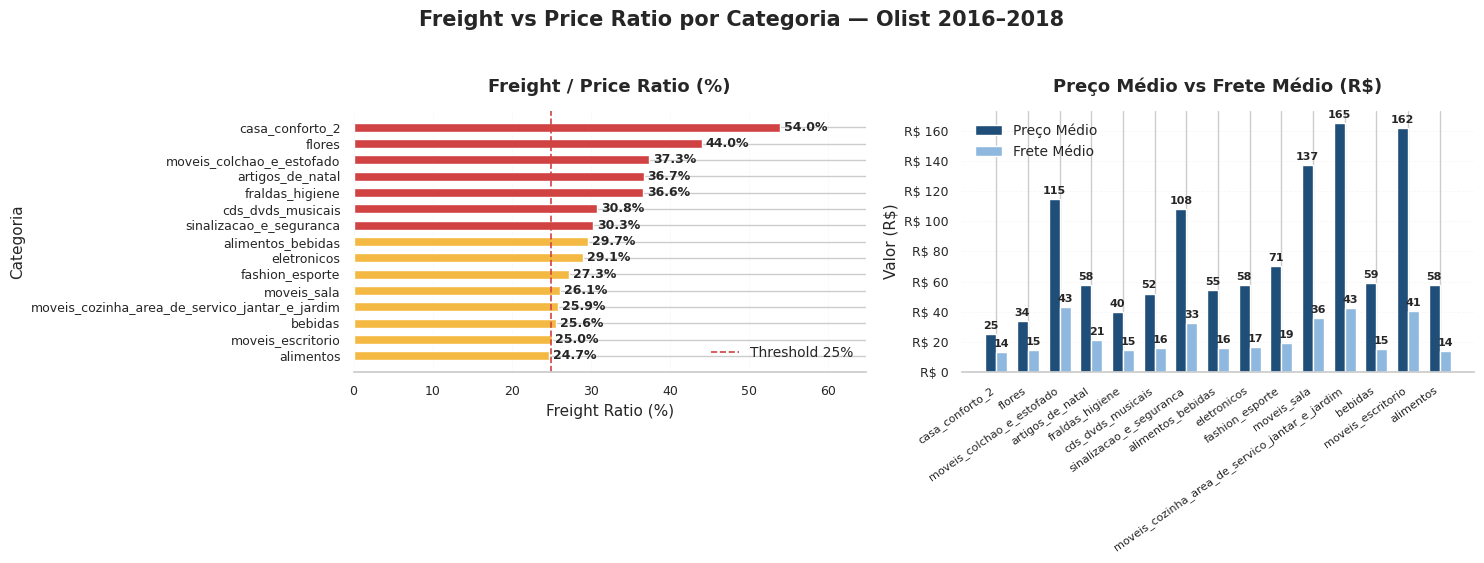

In [ ]:
# ================================================
# STEP 7: FREIGHT VS PRICE RATIO POR CATEGORIA
# ================================================
# Analisa a proporção do frete em relação ao preço
# por categoria
# Categorias com ratio alto indicam possível
# impacto na margem operacional

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ================================================
# CONSULTA SQL
# ================================================
query = """
SELECT
    p.product_category_name,
    COUNT(oi.order_item_id) AS total_items,
    ROUND(AVG(CAST(oi.price AS FLOAT)), 2) AS avg_price,
    ROUND(AVG(CAST(oi.freight_value AS FLOAT)), 2) AS avg_freight,
    ROUND(
        AVG(CAST(oi.freight_value AS FLOAT)) /
        NULLIF(AVG(CAST(oi.price AS FLOAT)), 0) * 100,
        2
    ) AS freight_ratio_pct
FROM olist_db.raw.order_items oi
LEFT JOIN olist_db.raw.products p
    ON oi.product_id = p.product_id
WHERE p.product_category_name IS NOT NULL
GROUP BY p.product_category_name
ORDER BY freight_ratio_pct DESC
LIMIT 15
"""

# ================================================
# CARGA DE DADOS
# ================================================
df_freight = pd.read_sql(query, conn)
df_freight.columns = df_freight.columns.str.lower()

print("📊 Freight vs Price Ratio por Categoria:")
print(df_freight.to_string(index=False))

# ================================================
# CONFIGURAÇÃO VISUAL
# ================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9
})

# ================================================
# CORES POR RISCO
# ================================================
colors_ratio = [
    "#D14343" if ratio > 30
    else "#F4B942" if ratio > 20
    else "#1F4E79"
    for ratio in df_freight["freight_ratio_pct"]
]

# ================================================
# FORMATADOR MONETÁRIO
# ================================================
def format_currency(value, position):
    return f"R$ {value:,.0f}".replace(",", ".")

# ================================================
# FIGURA PRINCIPAL
# ================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5),
    facecolor="white"
)

fig.suptitle(
    "Freight vs Price Ratio por Categoria — Olist 2016–2018",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

# ================================================
# GRÁFICO 1
# FREIGHT / PRICE RATIO
# ================================================
bars1 = axes[0].barh(
    df_freight["product_category_name"],
    df_freight["freight_ratio_pct"],
    color=colors_ratio,
    height=0.55
)

# ================================================
# THRESHOLD
# ================================================
axes[0].axvline(
    25,
    color="#D14343",
    linestyle="--",
    linewidth=1.2,
    label="Threshold 25%"
)

# ================================================
# LABELS
# ================================================
for bar, value in zip(
    bars1,
    df_freight["freight_ratio_pct"]
):
    axes[0].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="bold"
    )

axes[0].invert_yaxis()

axes[0].set_title(
    "Freight / Price Ratio (%)",
    fontweight="bold",
    pad=14
)

axes[0].set_xlabel("Freight Ratio (%)")
axes[0].set_ylabel("Categoria")

axes[0].set_xlim(
    0,
    df_freight["freight_ratio_pct"].max() * 1.20
)

axes[0].grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.15
)

axes[0].legend(
    frameon=False,
    fontsize=10
)

# ================================================
# GRÁFICO 2
# PREÇO MÉDIO VS FRETE MÉDIO
# ================================================
x = np.arange(len(df_freight))
width = 0.35

bars2 = axes[1].bar(
    x - width / 2,
    df_freight["avg_price"],
    width,
    label="Preço Médio",
    color="#1F4E79"
)

bars3 = axes[1].bar(
    x + width / 2,
    df_freight["avg_freight"],
    width,
    label="Frete Médio",
    color="#8FB8DE"
)

# ================================================
# LABELS
# ================================================
for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{bar.get_height():.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

for bar in bars3:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{bar.get_height():.0f}",
        ha="center",
        va="bottom",
        fontsize=8,
        fontweight="bold"
    )

axes[1].set_title(
    "Preço Médio vs Frete Médio (R$)",
    fontweight="bold",
    pad=14
)

axes[1].set_ylabel("Valor (R$)")

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    df_freight["product_category_name"],
    rotation=35,
    ha="right",
    fontsize=8
)

axes[1].yaxis.set_major_formatter(
    FuncFormatter(format_currency)
)

axes[1].grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.15
)

axes[1].legend(
    frameon=False,
    fontsize=10
)

# ================================================
# ACABAMENTO
# ================================================
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "step_07_freight_ratio.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

📊 Distribuição de Review Score:
review_score  total  percentual  avg_price  avg_freight
           5  63596       56.21     121.22        19.57
           4  21348       18.87     118.60        20.05
           3   9476        8.38     110.06        20.29
           2   3936        3.48     115.85        20.94
           1  14775       13.06     127.35        21.21


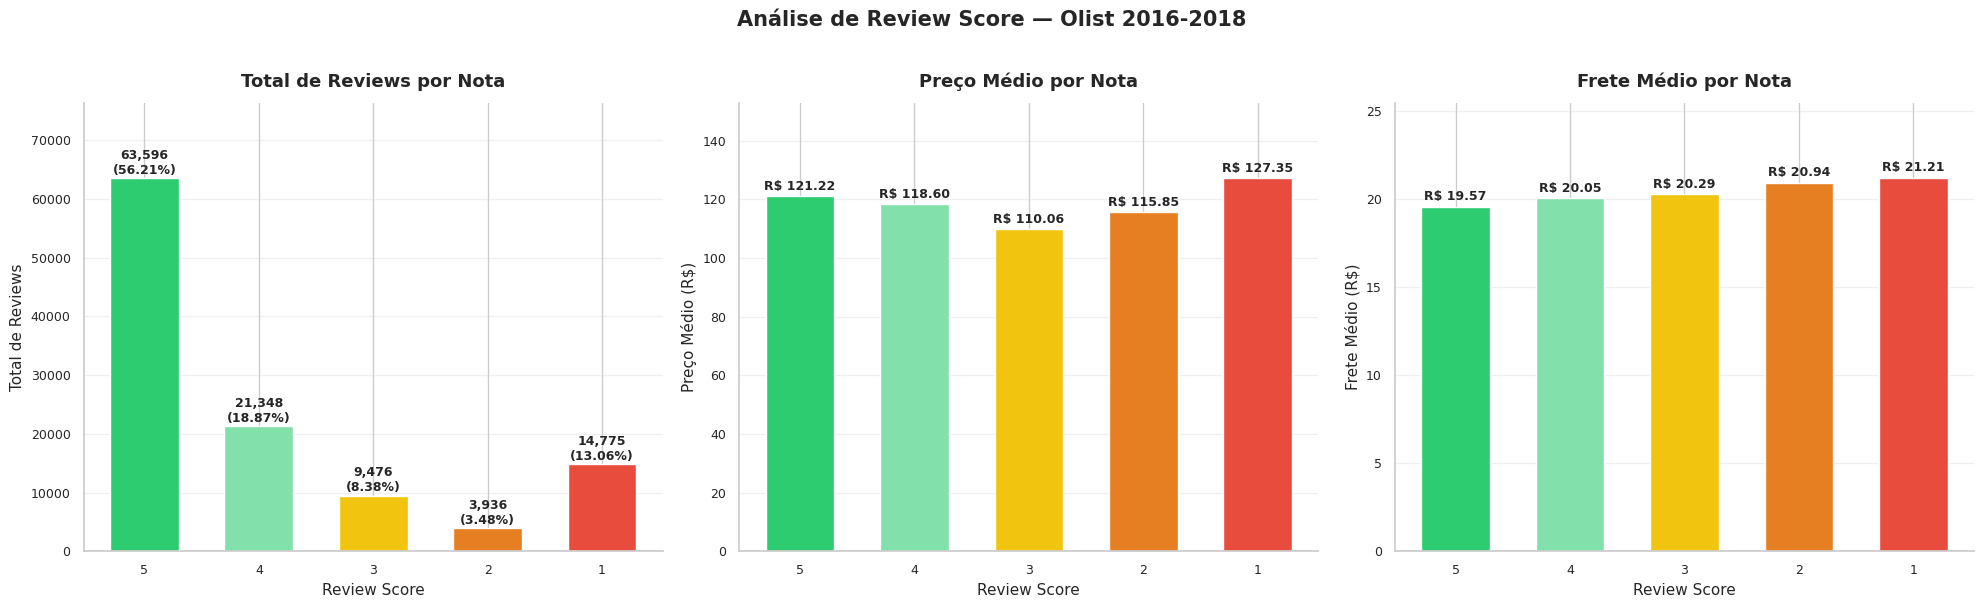

In [ ]:
# ================================================
# STEP 8: DISTRIBUIÇÃO DE REVIEW SCORE
# ================================================
# Analisa a distribuição das notas de avaliação
# e correlaciona com preço médio e frete médio
# Identifica se produtos mais caros geram mais insatisfação

query = """
SELECT
    ore.review_score,                                               -- nota da avaliação
    COUNT(*) AS total,                                              -- total de reviews
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentual, -- percentual
    ROUND(AVG(CAST(oi.price AS FLOAT)), 2) AS avg_price,            -- preço médio
    ROUND(AVG(CAST(oi.freight_value AS FLOAT)), 2) AS avg_freight   -- frete médio
FROM olist_db.raw.order_reviews ore
LEFT JOIN olist_db.raw.order_items oi                               -- traz preço e frete
    ON ore.order_id = oi.order_id
GROUP BY ore.review_score
ORDER BY ore.review_score DESC
"""

# Carrega dados e padroniza colunas
df_reviews = pd.read_sql(query, conn)
df_reviews.columns = df_reviews.columns.str.lower()

print("📊 Distribuição de Review Score:")
print(df_reviews.to_string(index=False))

# Cores por nota — verde para 5, vermelho para 1
colors_score = ['#2ecc71', '#82e0aa', '#f1c40f', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Análise de Review Score — Olist 2016-2018',
             fontsize=15, fontweight='bold', y=1.01)

# ── Gráfico 1: Distribuição de notas ───────────────────────
bars = axes[0].bar(
    df_reviews['review_score'].astype(str),  # notas como string no eixo x
    df_reviews['total'],                      # total no eixo y
    color=colors_score,                       # verde=5, vermelho=1
    edgecolor='white',
    width=0.6)

# Adiciona valor + percentual no topo de cada barra
for bar, row in zip(bars, df_reviews.itertuples()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,   # centro horizontal
        bar.get_height() + 200,               # topo + offset
        f"{row.total:,}\n({row.percentual}%)", # valor + percentual
        ha='center', va='bottom',
        fontsize=9, fontweight='bold')

axes[0].set_title('Total de Reviews por Nota', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Review Score', fontsize=11)
axes[0].set_ylabel('Total de Reviews', fontsize=11)
axes[0].set_ylim(0, df_reviews['total'].max() * 1.2)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# ── Gráfico 2: Preço médio por nota ────────────────────────
bars2 = axes[1].bar(
    df_reviews['review_score'].astype(str),  # notas no eixo x
    df_reviews['avg_price'],                  # preço médio no eixo y
    color=colors_score,                       # mesmas cores
    edgecolor='white',
    width=0.6)

# Adiciona valor no topo
for bar, value in zip(bars2, df_reviews['avg_price']):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"R$ {value:.2f}",                   # formato monetário
        ha='center', va='bottom',
        fontsize=9, fontweight='bold')

axes[1].set_title('Preço Médio por Nota', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Review Score', fontsize=11)
axes[1].set_ylabel('Preço Médio (R$)', fontsize=11)
axes[1].set_ylim(0, df_reviews['avg_price'].max() * 1.2)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

# ── Gráfico 3: Frete médio por nota ────────────────────────
bars3 = axes[2].bar(
    df_reviews['review_score'].astype(str),  # notas no eixo x
    df_reviews['avg_freight'],                # frete médio no eixo y
    color=colors_score,                       # mesmas cores
    edgecolor='white',
    width=0.6)

# Adiciona valor no topo
for bar, value in zip(bars3, df_reviews['avg_freight']):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"R$ {value:.2f}",
        ha='center', va='bottom',
        fontsize=9, fontweight='bold')

axes[2].set_title('Frete Médio por Nota', fontsize=13, fontweight='bold', pad=12)
axes[2].set_xlabel('Review Score', fontsize=11)
axes[2].set_ylabel('Frete Médio (R$)', fontsize=11)
axes[2].set_ylim(0, df_reviews['avg_freight'].max() * 1.2)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('step_08_review_score.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Top 8 Sellers por Receita:
       seller_label  total_revenue  avg_price  revenue_share_pct
         Guariba/SP      229472.63     198.51               1.69
Lauro De Freitas/BA      222776.05     543.36               1.64
        Ibitinga/SP      200472.92     100.89               1.47
          Sumare/SP      194042.03     331.13               1.43
 Itaquaquecetuba/SP      187923.89     137.77               1.38
         Barueri/SP      176431.87     518.92               1.30
      Piracicaba/SP      160236.57     103.31               1.18
       Sao Paulo/SP      141745.53     121.05               1.04


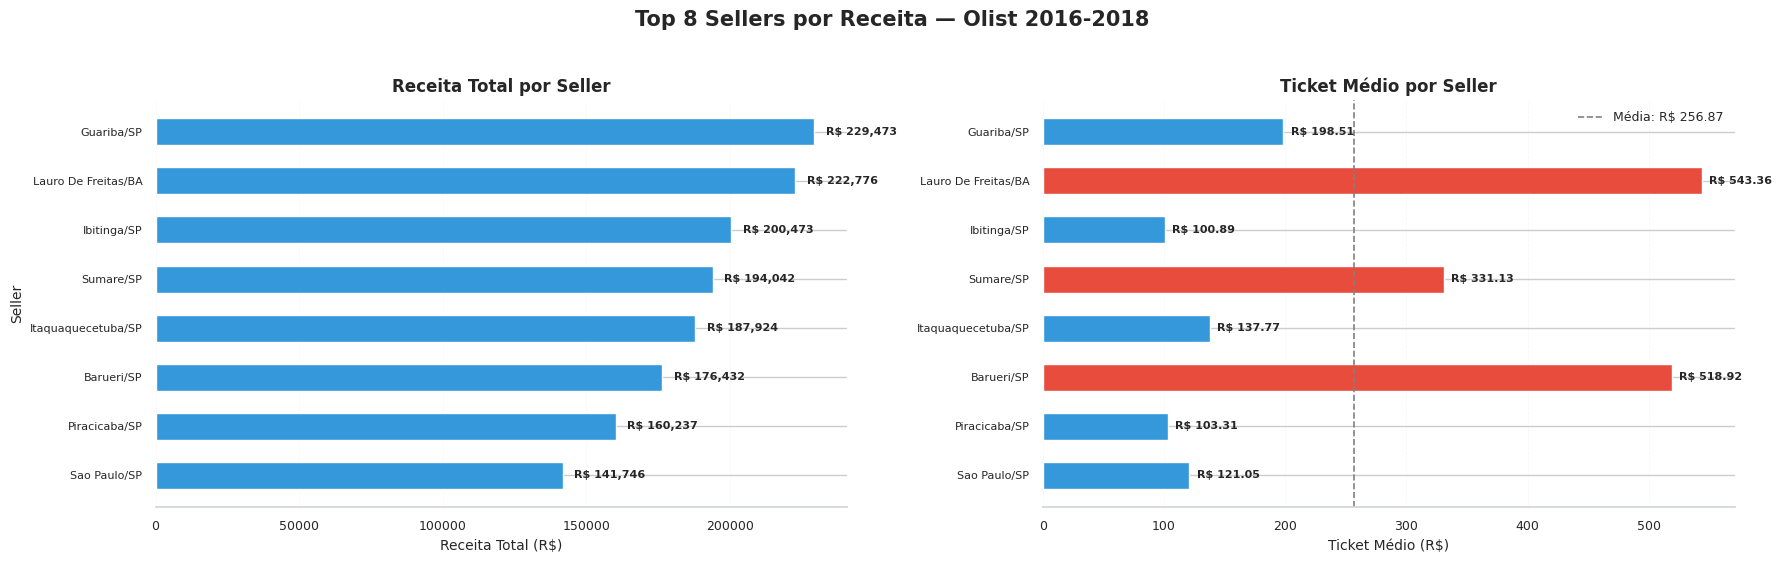

In [86]:
# ================================================
# STEP 9: TOP 8 SELLERS POR RECEITA
# ================================================
# Identifica sellers com maior receita e ticket médio
# reduzido para top 8 para melhor leitura visual

import pandas as pd
import matplotlib.pyplot as plt

# ================================================
# CONSULTA SQL
# ================================================
query = """
SELECT
    s.seller_id,
    s.seller_city,
    s.seller_state,
    COUNT(DISTINCT oi.order_id) AS total_orders,
    COUNT(oi.order_item_id) AS total_items,
    ROUND(SUM(CAST(oi.price AS FLOAT)), 2) AS total_revenue,
    ROUND(AVG(CAST(oi.price AS FLOAT)), 2) AS avg_price,
    ROUND(
        SUM(CAST(oi.price AS FLOAT)) * 100.0 /
        SUM(SUM(CAST(oi.price AS FLOAT))) OVER(),
        2
    ) AS revenue_share_pct
FROM olist_db.raw.sellers s
LEFT JOIN olist_db.raw.order_items oi
    ON s.seller_id = oi.seller_id
GROUP BY
    s.seller_id,
    s.seller_city,
    s.seller_state
ORDER BY total_revenue DESC
LIMIT 8
"""

# ================================================
# CARGA DE DADOS
# ================================================
df_sellers = pd.read_sql(query, conn)
df_sellers.columns = df_sellers.columns.str.lower()

# ================================================
# LABEL CIDADE / ESTADO
# ================================================
df_sellers["seller_label"] = (
    df_sellers["seller_city"].str.title()
    + "/"
    + df_sellers["seller_state"]
)

print("📊 Top 8 Sellers por Receita:")

print(
    df_sellers[
        [
            "seller_label",
            "total_revenue",
            "avg_price",
            "revenue_share_pct"
        ]
    ].to_string(index=False)
)

# ================================================
# VISUAL
# ================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 8
})

# ================================================
# FIGURA
# ================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 5.5),
    facecolor="white"
)

fig.suptitle(
    "Top 8 Sellers por Receita — Olist 2016-2018",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

# ================================================
# RECEITA TOTAL
# ================================================
bars1 = axes[0].barh(
    df_sellers["seller_label"],
    df_sellers["total_revenue"],
    color="#3498db",
    height=0.55
)

for bar, revenue in zip(
    bars1,
    df_sellers["total_revenue"]
):

    axes[0].text(
        revenue + 4000,
        bar.get_y() + bar.get_height()/2,
        f"R$ {revenue:,.0f}",
        va="center",
        ha="left",
        fontsize=8,
        fontweight="bold"
    )

axes[0].invert_yaxis()

axes[0].set_title(
    "Receita Total por Seller",
    fontweight="bold"
)

axes[0].set_xlabel("Receita Total (R$)")
axes[0].set_ylabel("Seller")

axes[0].grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.15
)

# ================================================
# TICKET MÉDIO
# ================================================
avg_price_mean = df_sellers["avg_price"].mean()

colors_avg = [
    "#e74c3c"
    if value > avg_price_mean
    else "#3498db"
    for value in df_sellers["avg_price"]
]

bars2 = axes[1].barh(
    df_sellers["seller_label"],
    df_sellers["avg_price"],
    color=colors_avg,
    height=0.55
)

axes[1].axvline(
    avg_price_mean,
    color="gray",
    linestyle="--",
    linewidth=1.2,
    label=f"Média: R$ {avg_price_mean:.2f}"
)

for bar, value in zip(
    bars2,
    df_sellers["avg_price"]
):

    axes[1].text(
        value + 6,
        bar.get_y() + bar.get_height()/2,
        f"R$ {value:,.2f}",
        va="center",
        ha="left",
        fontsize=8,
        fontweight="bold"
    )

axes[1].invert_yaxis()

axes[1].set_title(
    "Ticket Médio por Seller",
    fontweight="bold"
)

axes[1].set_xlabel("Ticket Médio (R$)")
axes[1].set_ylabel("")

axes[1].grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.15
)

axes[1].legend(
    frameon=False,
    fontsize=9
)

# ================================================
# ACABAMENTO
# ================================================
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "step_09_top_sellers.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

📊 Price Outliers por Categoria:
 product_category_name  avg_price  lower_bound  upper_bound  outliers_above
          beleza_saude     130.16       -94.88       264.77            1174
             telefonia      71.21       -18.53        89.52             789
      moveis_decoracao      87.56       -50.10       189.90             712
    relogios_presentes     201.14      -165.14       435.07             630
         esporte_lazer     114.34       -84.19       258.50             579
    ferramentas_jardim     111.63       -25.10       174.90             533
       cama_mesa_banho      93.30       -52.52       215.52             497
            brinquedos     117.55       -75.15       252.93             396
 utilidades_domesticas      90.79       -91.14       237.24             395
            automotivo     139.96      -137.44       334.38             342
           eletronicos      57.91       -45.13       114.92             342
informatica_acessorios     116.51      -123.75       312

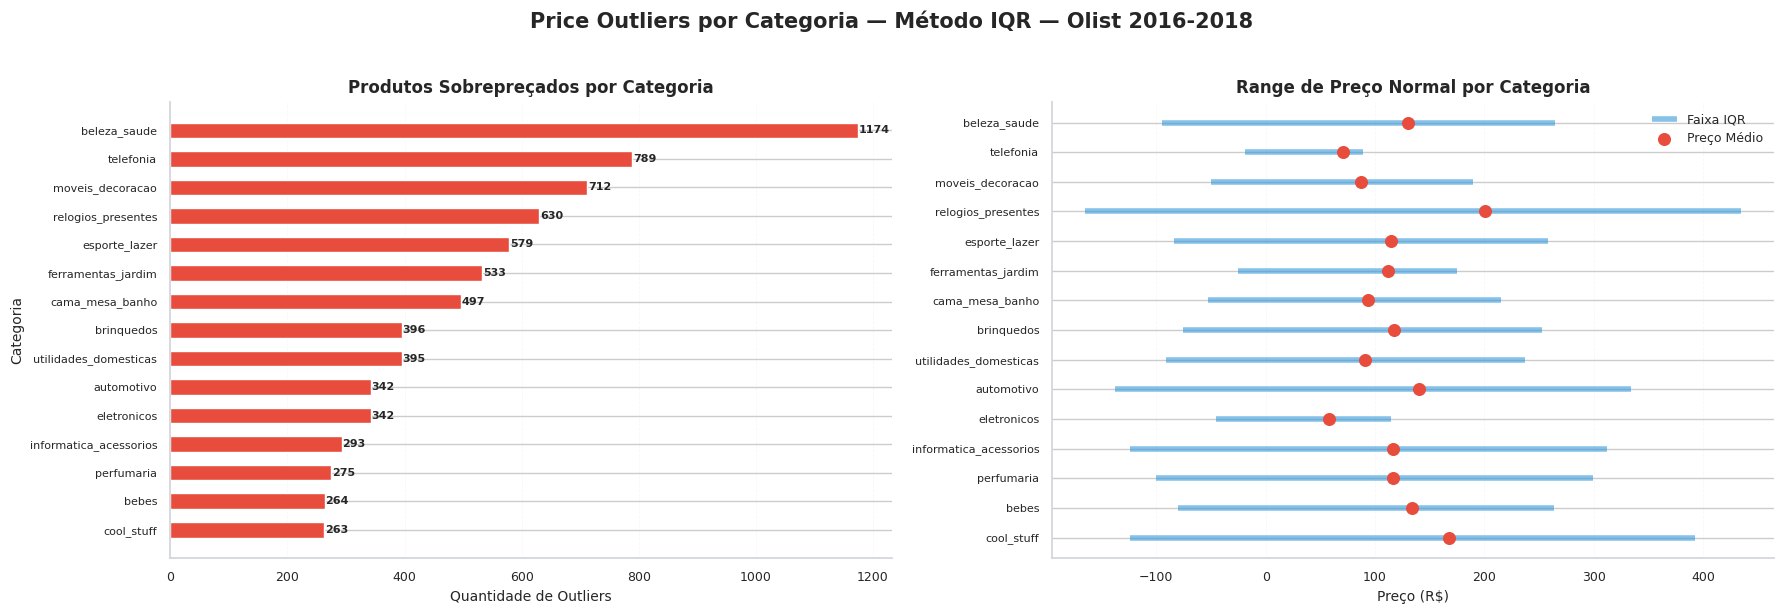

In [84]:
# ================================================
# STEP 10: PRICE OUTLIERS POR CATEGORIA
# ================================================
# Detecta produtos com preço fora do padrão
# usando IQR (Interquartile Range)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================================
# CONSULTA SQL
# ================================================
query = """
WITH base_prices AS (

    SELECT
        p.product_category_name,
        CAST(oi.price AS FLOAT) AS price

    FROM olist_db.raw.order_items oi

    LEFT JOIN olist_db.raw.products p
        ON oi.product_id = p.product_id

    WHERE p.product_category_name IS NOT NULL
),

quartiles AS (

    SELECT DISTINCT
        product_category_name,

        PERCENTILE_CONT(0.25)
            WITHIN GROUP (ORDER BY price)
            OVER (
                PARTITION BY product_category_name
            ) AS q1,

        PERCENTILE_CONT(0.75)
            WITHIN GROUP (ORDER BY price)
            OVER (
                PARTITION BY product_category_name
            ) AS q3

    FROM base_prices
),

final_stats AS (

    SELECT
        b.product_category_name,

        COUNT(*) AS total_items,

        ROUND(AVG(price), 2) AS avg_price,

        ROUND(MIN(price), 2) AS min_price,

        ROUND(MAX(price), 2) AS max_price,

        ROUND(q.q1, 2) AS q1,

        ROUND(q.q3, 2) AS q3,

        ROUND(q.q3 - q.q1, 2) AS iqr,

        ROUND(
            q.q1 - 1.5 * (q.q3 - q.q1),
            2
        ) AS lower_bound,

        ROUND(
            q.q3 + 1.5 * (q.q3 - q.q1),
            2
        ) AS upper_bound,

        SUM(
            CASE
                WHEN price >
                     q.q3 + 1.5 * (q.q3 - q.q1)
                THEN 1
                ELSE 0
            END
        ) AS outliers_above,

        SUM(
            CASE
                WHEN price <
                     q.q1 - 1.5 * (q.q3 - q.q1)
                THEN 1
                ELSE 0
            END
        ) AS outliers_below

    FROM base_prices b

    INNER JOIN quartiles q
        ON b.product_category_name =
           q.product_category_name

    GROUP BY
        b.product_category_name,
        q.q1,
        q.q3
)

SELECT *
FROM final_stats
ORDER BY outliers_above DESC
LIMIT 15
"""

# ================================================
# CARGA
# ================================================
df_outliers = pd.read_sql(query, conn)
df_outliers.columns = df_outliers.columns.str.lower()

print("📊 Price Outliers por Categoria:")
print(
    df_outliers[
        [
            "product_category_name",
            "avg_price",
            "lower_bound",
            "upper_bound",
            "outliers_above"
        ]
    ].to_string(index=False)
)

# ================================================
# VISUAL
# ================================================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 8
})

# ================================================
# FIGURA
# ================================================
fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 6),
    facecolor="white"
)

fig.suptitle(
    "Price Outliers por Categoria — Método IQR — Olist 2016-2018",
    fontsize=15,
    fontweight="bold",
    y=1.02
)

# ================================================
# GRÁFICO 1
# OUTLIERS ACIMA
# ================================================
bars = axes[0].barh(
    df_outliers["product_category_name"],
    df_outliers["outliers_above"],
    color="#e74c3c",
    height=0.55
)

for bar, value in zip(
    bars,
    df_outliers["outliers_above"]
):
    axes[0].text(
        value + 1,
        bar.get_y() + bar.get_height()/2,
        f"{value}",
        va="center",
        ha="left",
        fontsize=8,
        fontweight="bold"
    )

axes[0].invert_yaxis()

axes[0].set_title(
    "Produtos Sobrepreçados por Categoria",
    fontweight="bold"
)

axes[0].set_xlabel("Quantidade de Outliers")
axes[0].set_ylabel("Categoria")

axes[0].grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.15
)

# ================================================
# GRÁFICO 2
# RANGE IQR
# ================================================
y_pos = np.arange(len(df_outliers))

axes[1].hlines(
    y_pos,
    df_outliers["lower_bound"],
    df_outliers["upper_bound"],
    linewidth=4,
    alpha=0.6,
    color="#3498db",
    label="Faixa IQR"
)

axes[1].scatter(
    df_outliers["avg_price"],
    y_pos,
    s=70,
    color="#e74c3c",
    label="Preço Médio",
    zorder=5
)

axes[1].set_yticks(y_pos)

axes[1].set_yticklabels(
    df_outliers["product_category_name"]
)

axes[1].invert_yaxis()

axes[1].set_title(
    "Range de Preço Normal por Categoria",
    fontweight="bold"
)

axes[1].set_xlabel("Preço (R$)")

axes[1].grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.15
)

axes[1].legend(
    frameon=False,
    fontsize=9
)

# ================================================
# ACABAMENTO
# ================================================
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "step_10_price_outliers.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

📊 Correlação Pearson (preço x satisfação): -0.0044

📊 Satisfação Média por Faixa de Preço:
price_range  avg_score  total
     R$0-50   4.035754  38597
   R$50-100   4.017084  32663
  R$100-200   4.062431  26333
  R$200-500   4.030923  10025
   R$500-1k   4.026158   2332
      R$1k+   3.939320    824


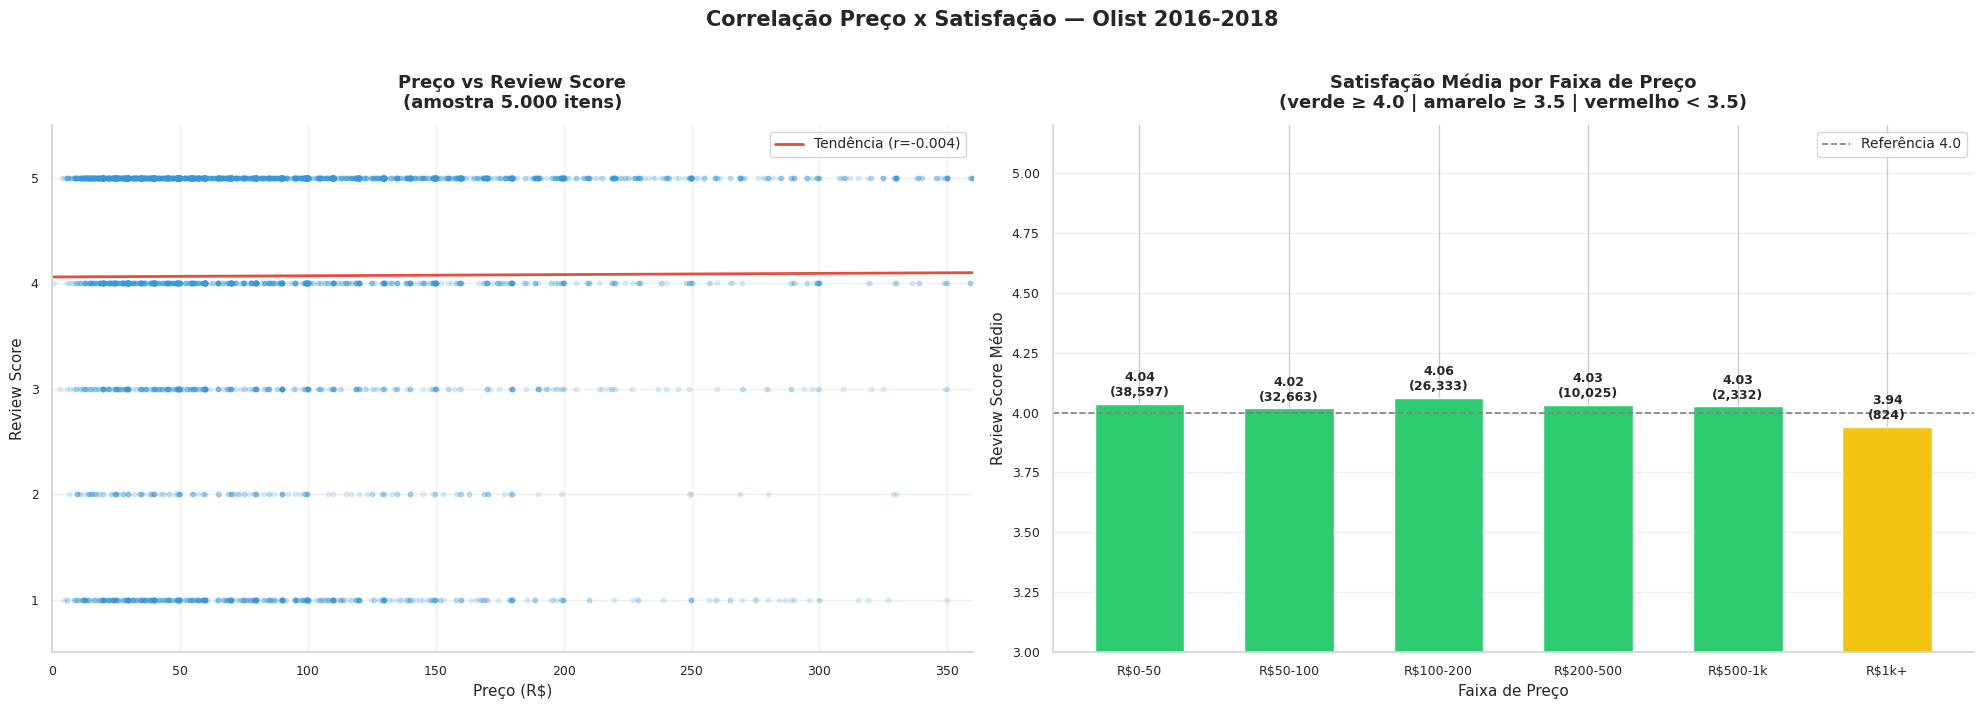

In [76]:
# ================================================
# STEP 11: CORRELAÇÃO PREÇO X SATISFAÇÃO
# ================================================
# Analisa se existe correlação entre o preço do produto
# e a nota de satisfação do cliente
# Identifica faixas de preço com maior e menor satisfação
# Fundamental para estratégia de pricing baseada em experiência

query = """
SELECT
    CAST(oi.price AS FLOAT) AS price,               -- preço do item
    CAST(ore.review_score AS FLOAT) AS review_score, -- nota da avaliação
    p.product_category_name,                          -- categoria do produto
    CAST(oi.freight_value AS FLOAT) AS freight_value  -- frete
FROM olist_db.raw.order_items oi
LEFT JOIN olist_db.raw.order_reviews ore              -- traz avaliação
    ON oi.order_id = ore.order_id
LEFT JOIN olist_db.raw.products p                     -- traz categoria
    ON oi.product_id = p.product_id
WHERE ore.review_score IS NOT NULL                    -- apenas com avaliação
AND p.product_category_name IS NOT NULL               -- apenas com categoria
"""

# Carrega dados e padroniza colunas
df_corr = pd.read_sql(query, conn)
df_corr.columns = df_corr.columns.str.lower()

# Calcula correlação de Pearson entre preço e satisfação
correlation = df_corr['price'].corr(df_corr['review_score'])
print(f"📊 Correlação Pearson (preço x satisfação): {correlation:.4f}")

# Cria faixas de preço para análise agrupada
# pd.cut divide os preços em 6 faixas iguais
df_corr['price_range'] = pd.cut(
    df_corr['price'],
    bins=[0, 50, 100, 200, 500, 1000, 10000],          # limites das faixas
    labels=['R$0-50', 'R$50-100', 'R$100-200',
            'R$200-500', 'R$500-1k', 'R$1k+'])          # labels das faixas

# Agrega satisfação média por faixa de preço
df_price_score = df_corr.groupby('price_range', observed=True).agg(
    avg_score=('review_score', 'mean'),    # satisfação média
    total=('review_score', 'count')        # total de reviews
).reset_index()

print("\n📊 Satisfação Média por Faixa de Preço:")
print(df_price_score.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Correlação Preço x Satisfação — Olist 2016-2018',
             fontsize=15, fontweight='bold', y=1.01)

# ── Gráfico 1: Scatter plot preço x satisfação ─────────────
# Amostra 5000 pontos para não sobrecarregar o gráfico
df_sample = df_corr.sample(n=min(5000, len(df_corr)),  # amostra aleatória
                            random_state=42)             # seed para reprodutibilidade

# Scatter com transparência para visualizar densidade
axes[0].scatter(
    df_sample['price'],          # eixo x = preço
    df_sample['review_score'],   # eixo y = nota
    alpha=0.15,                  # transparência — densidade visível
    color='#3498db',             # azul
    s=10)                        # tamanho dos pontos

# Linha de tendência — regressão linear
z = np.polyfit(df_sample['price'],           # ajusta linha de tendência
               df_sample['review_score'], 1)  # grau 1 = linear
p = np.poly1d(z)                              # cria função da linha
x_line = np.linspace(df_sample['price'].min(),
                     df_sample['price'].max(), 100)  # pontos da linha
axes[0].plot(x_line, p(x_line),              # plota linha de tendência
             color='#e74c3c',                # vermelho
             linewidth=2,
             label=f'Tendência (r={correlation:.3f})')

axes[0].set_title('Preço vs Review Score\n(amostra 5.000 itens)',
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Preço (R$)', fontsize=11)
axes[0].set_ylabel('Review Score', fontsize=11)
axes[0].set_xlim(0, df_sample['price'].quantile(0.95))  # limita ao percentil 95
axes[0].set_ylim(0.5, 5.5)                               # range das notas
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=10)

# ── Gráfico 2: Satisfação média por faixa de preço ─────────
# Cores baseadas na nota — verde=alta satisfação, vermelho=baixa
colors_score = ['#2ecc71' if s >= 4.0 else '#f1c40f' if s >= 3.5 else '#e74c3c'
                for s in df_price_score['avg_score']]

bars = axes[1].bar(
    df_price_score['price_range'].astype(str),  # faixas de preço
    df_price_score['avg_score'],                 # satisfação média
    color=colors_score,                          # verde=boa, amarelo=média, vermelho=ruim
    edgecolor='white',
    width=0.6)

# Linha de referência — nota 4.0
axes[1].axhline(4.0, color='gray', linestyle='--',
                linewidth=1.2, label='Referência 4.0')

# Adiciona nota + total de reviews no topo de cada barra
for bar, row in zip(bars, df_price_score.itertuples()):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{row.avg_score:.2f}\n({row.total:,})",  # nota + quantidade
        ha='center', va='bottom',
        fontsize=9, fontweight='bold')

axes[1].set_title('Satisfação Média por Faixa de Preço\n(verde ≥ 4.0 | amarelo ≥ 3.5 | vermelho < 3.5)',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Faixa de Preço', fontsize=11)
axes[1].set_ylabel('Review Score Médio', fontsize=11)
axes[1].set_ylim(3.0, 5.2)                 # range relevante das notas
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('step_11_preco_satisfacao.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Sazonalidade de Vendas por Mês:
       mes  total_orders  total_items  total_revenue  avg_price
2016-09-01             1            3         134.97      44.99
2016-10-01           265          313       40325.11     128.83
2016-12-01             1            1          10.90      10.90
2017-01-01           750          913      111798.36     122.45
2017-02-01          1653         1858      234223.40     126.06
2017-03-01          2546         2897      359198.85     123.99
2017-04-01          2303         2569      340669.68     132.61
2017-05-01          3546         4004      489338.25     122.21
2017-06-01          3135         3489      421923.37     120.93
2017-07-01          3872         4416      481604.52     109.06
2017-08-01          4193         4797      554699.70     115.63
2017-09-01          4150         4737      607399.67     128.22
2017-10-01          4478         5214      648247.65     124.33
2017-11-01          7289         8475      987765.37     116.55
2017-1

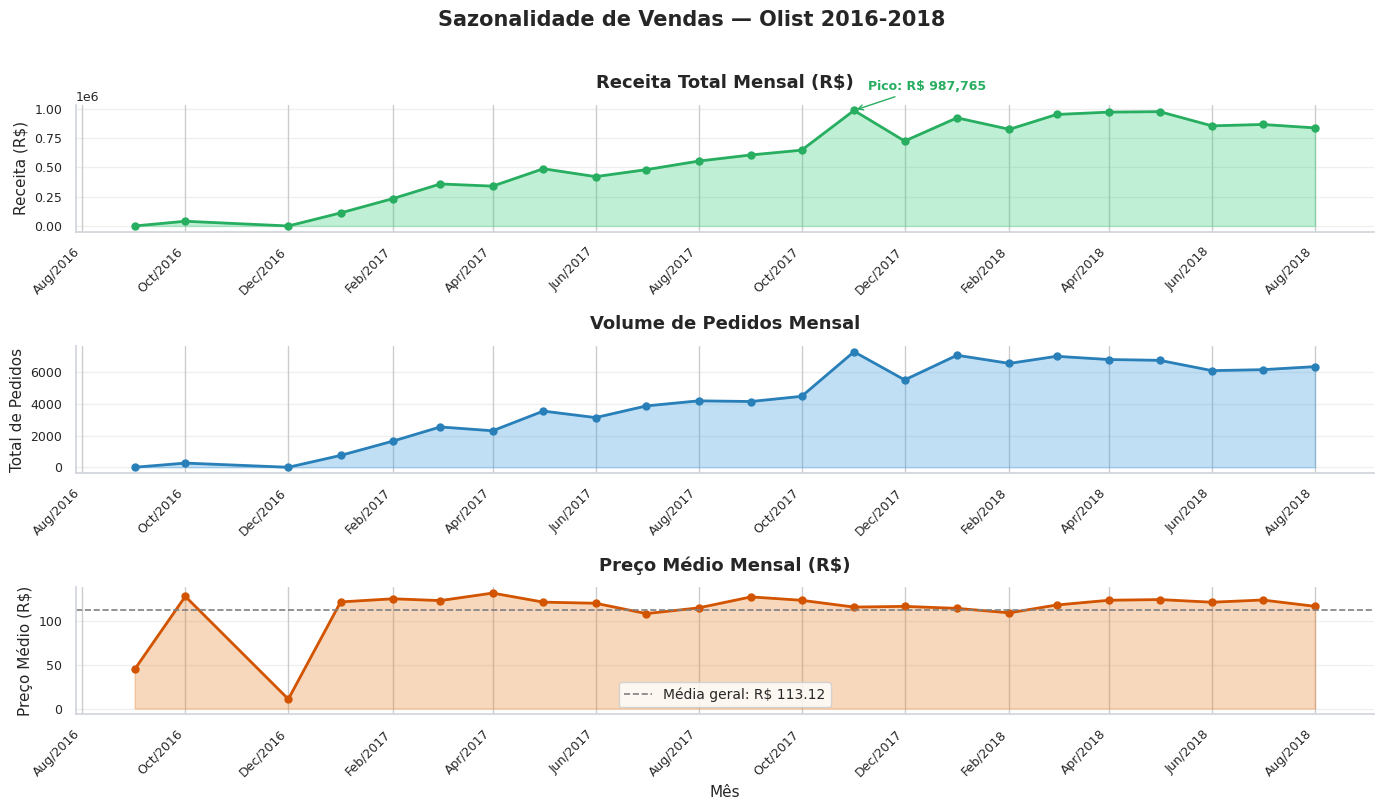

In [80]:
# ================================================
# STEP 12: SAZONALIDADE DE VENDAS
# ================================================
# Analisa o comportamento de vendas ao longo do tempo
# Identifica sazonalidade mensal e anual
# Fundamental para estratégia de pricing dinâmico
# Ex: aumentar preço em períodos de alta demanda

query = """
SELECT
    DATE_TRUNC('month', CAST(o.order_purchase_timestamp AS TIMESTAMP)) AS mes,  -- trunca para mês
    COUNT(DISTINCT o.order_id) AS total_orders,                                  -- pedidos únicos
    COUNT(oi.order_item_id) AS total_items,                                      -- itens vendidos
    ROUND(SUM(CAST(oi.price AS FLOAT)), 2) AS total_revenue,                     -- receita total
    ROUND(AVG(CAST(oi.price AS FLOAT)), 2) AS avg_price                          -- preço médio
FROM olist_db.raw.orders o
LEFT JOIN olist_db.raw.order_items oi                                            -- traz itens
    ON o.order_id = oi.order_id
WHERE o.order_status = 'delivered'                                               -- apenas entregues
AND o.order_purchase_timestamp IS NOT NULL                                       -- remove nulos
GROUP BY DATE_TRUNC('month', CAST(o.order_purchase_timestamp AS TIMESTAMP))
ORDER BY mes
"""

# Carrega dados e padroniza colunas
df_seasonal = pd.read_sql(query, conn)
df_seasonal.columns = df_seasonal.columns.str.lower()

# Converte coluna mes para datetime para plotagem correta
df_seasonal['mes'] = pd.to_datetime(df_seasonal['mes'])

print("📊 Sazonalidade de Vendas por Mês:")
print(df_seasonal.to_string(index=False))

fig, axes = plt.subplots(3, 1, figsize=(14, 8))
fig.suptitle('Sazonalidade de Vendas — Olist 2016-2018',
             fontsize=15, fontweight='bold', y=1.01)

# ── Gráfico 1: Receita mensal ───────────────────────────────
axes[0].fill_between(
    df_seasonal['mes'],            # eixo x = mês
    df_seasonal['total_revenue'],  # eixo y = receita
    alpha=0.3,                     # transparência do preenchimento
    color='#2ecc71')               # verde

axes[0].plot(
    df_seasonal['mes'],            # linha sobre o preenchimento
    df_seasonal['total_revenue'],
    color='#27ae60',               # verde escuro
    linewidth=2,
    marker='o',                    # marcador em cada ponto
    markersize=5)

# Destaca o pico de receita
max_rev_idx = df_seasonal['total_revenue'].idxmax()  # índice do maior valor
axes[0].annotate(
    f"Pico: R$ {df_seasonal['total_revenue'].max():,.0f}",  # texto do pico
    xy=(df_seasonal['mes'].iloc[max_rev_idx],
        df_seasonal['total_revenue'].iloc[max_rev_idx]),
    xytext=(10, 15), textcoords='offset points',
    fontsize=9, fontweight='bold', color='#27ae60',
    arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1))

axes[0].set_title('Receita Total Mensal (R$)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_ylabel('Receita (R$)', fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# ── Gráfico 2: Volume de pedidos mensal ────────────────────
axes[1].fill_between(
    df_seasonal['mes'],
    df_seasonal['total_orders'],   # eixo y = pedidos
    alpha=0.3,
    color='#3498db')               # azul

axes[1].plot(
    df_seasonal['mes'],
    df_seasonal['total_orders'],
    color='#2980b9',               # azul escuro
    linewidth=2,
    marker='o',
    markersize=5)

axes[1].set_title('Volume de Pedidos Mensal', fontsize=13, fontweight='bold', pad=12)
axes[1].set_ylabel('Total de Pedidos', fontsize=11)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].grid(axis='y', alpha=0.3)

# ── Gráfico 3: Preço médio mensal ──────────────────────────
axes[2].fill_between(
    df_seasonal['mes'],
    df_seasonal['avg_price'],      # eixo y = preço médio
    alpha=0.3,
    color='#e67e22')               # laranja

axes[2].plot(
    df_seasonal['mes'],
    df_seasonal['avg_price'],
    color='#d35400',               # laranja escuro
    linewidth=2,
    marker='o',
    markersize=5)

# Linha de referência — preço médio geral
avg_price_geral = df_seasonal['avg_price'].mean()  # média de todo o período
axes[2].axhline(
    avg_price_geral,
    color='gray', linestyle='--',
    linewidth=1.2,
    label=f'Média geral: R$ {avg_price_geral:.2f}')

axes[2].set_title('Preço Médio Mensal (R$)', fontsize=13, fontweight='bold', pad=12)
axes[2].set_xlabel('Mês', fontsize=11)
axes[2].set_ylabel('Preço Médio (R$)', fontsize=11)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)
axes[2].grid(axis='y', alpha=0.3)
axes[2].legend(fontsize=10)

# Formata o eixo x com mês/ano para todos os gráficos
import matplotlib.dates as mdates
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))  # formato Mês/Ano
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # tick a cada 2 meses
    plt.setp(ax.xaxis.get_majorticklabels(),                     # rotaciona labels
             rotation=45, ha='right')

plt.tight_layout()
plt.savefig('step_12_sazonalidade.png', dpi=150, bbox_inches='tight')
plt.show()